<a href="https://colab.research.google.com/github/BruceLEE6/FCV-EMS-raw/blob/main/RLCHPFC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd drive/My\ Drive/RLCHPFC

/content/drive/My Drive/RLCHPFC


In [ ]:
# Stable Baselines only supports tensorflow 1.x for now
%tensorflow_version 1.x
!pip install stable-baselines[mpi]==2.10.0

TensorFlow 1.x selected.
     |████████████████████████████████| 248 kB 28.8 MB/s 
  Attempting uninstall: stable-baselines
    Found existing installation: stable-baselines 2.2.1
    Uninstalling stable-baselines-2.2.1:
      Successfully uninstalled stable-baselines-2.2.1


CHPFC env:

In [ ]:
import gym
from gym import spaces
from gym.utils import seeding
import numpy as np
from os import path
import math
import scipy.io as sio
#path.exists(path)

class FcchpmEnv(gym.Env):
    metadata = {
        'render.modes': ['human', 'rgb_array'],
        'video.frames_per_second': 30
    }

    def __init__(self):
        self.max_soc = 95   # 75
        self.min_soc = 35   # 30
        self.mean_soc = 0.5*(self.min_soc+self.max_soc)
        self.std_soc = 0.5 * (self.max_soc-self.min_soc)
        self.alpha = 0.003  # weight of SOC variation

        self.min_I_fc = -1.0  # minimum normalized FC current
        self.I_fc_norm = 48.0     # nominal FC current (A)
        self.max_I_fc = 1.0   # maximum normalized FC current
        self.N_cell = 48.0   # fuel cell number in stack
        self.A_cell = 96.0    # active area (cm2)
        self.T_fc = 70.0
        self.A_surface = 0.1    # fuel cell surface 0.1 (m2)

        self.min_t_w = 35.0    # maximum temperature (oC)
        self.max_t_w = 65.0   # maximum temperature (oC)
        self.mean_t_w = 0.5*(self.min_t_w+self.max_t_w)
        self.std_t_w = 0.5 * (self.max_t_w-self.min_t_w)
        self.v_w = 0.6  # water volume (m3)
        self.beta = 0.003  # weight for water temperature variation

        self.T_s = 360.0   # sample time (s)
        # data of 241 samples
        #print('OK')
        #self.P_load_th = np.load('data.npy')[0][0]*1000   # thermal load (W)
        self.P_load_th = np.load('data_week.npy')[0][0] * 1000  # thermal load (W)
        self.mean_p_th = np.mean(self.P_load_th)
        self.std_p_th = np.std(self.P_load_th)
        #self.P_load_e = np.load('data.npy')[1][0]*1000  # elec load (W)
        self.P_load_e = np.load('data_week.npy')[1][0] * 1000  # elec load (W)
        self.mean_p_e = np.mean(self.P_load_e)
        self.std_p_e = np.std(self.P_load_e)
        self.T_a = np.load('data_week.npy')[2][0]  # outdoor air temperature (oC)
        #self.T_a = np.load('data.npy')[2][0]  # outdoor air temperature (oC)
        self.mean_T_a = np.mean(self.T_a)
        self.std_T_a = np.std(self.T_a)

        #self.N_step = 241   # to evaluate the last-step cost
        self.N_step = 1687  # to evaluate the last-step cost

        low_action = np.array([self.min_I_fc, -1], dtype=np.float32)
        high_action = np.array([self.max_I_fc, 1], dtype=np.float32)
        self.action_space = spaces.Box(
            low=low_action,
            high=high_action,
            dtype=np.float32
        )
        # state vector [soc, t_w, t_a, p_e, p_t]
        low_state = np.array([-1.5, -1.5, -5.0, -5.0, -5.0], dtype=np.float32)
        high_state = np.array([1.5, 1.5, 5.0, 5.0, 5.0], dtype=np.float32)
        self.observation_space = spaces.Box(
            low = low_state,
            high = high_state,
            dtype = np.float32
        )
        self.seed()

    def seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def step(self, u): # u = normalized FC current
        F = 96485   # Faraday constant
        Delta_h2 = 285.85   # lower heating kJ/mol
        soc_last_std, t_w_last_std, t_a_std, p_e_std, p_th_std = self._get_obs()
        # soc_last = soc_last_std*self.std_soc+self.mean_soc
        # t_w_last = t_w_last_std*self.std_t_w+self.mean_t_w
        # t_a  = t_a_std*self.std_T_a+self.mean_T_a
        p_e = p_e_std*self.std_p_e+self.mean_p_e
        p_th = p_th_std*self.std_p_th+self.mean_p_th
        _, _, index = self.state
        i_norm = np.clip(u[0], self.min_I_fc, self.max_I_fc)
        alpha_norm = np.clip(u[1], -1.0, 1.0)
        alpha = (alpha_norm+1)*0.5
        # FC elec part
        i_fc = (i_norm+1)*self.I_fc_norm*0.5
        p_loss_aux = 50 + 0.5 * i_fc * 2    # auxiliary electric loss power(W)
        i_den = i_fc/self.A_cell
        v_cell = self.model_fc(i_den)
        v_stack = v_cell * self.N_cell
        p_ele_total = i_fc * v_stack
        p_fc_ele = p_ele_total - p_loss_aux     # fuel cell net electrical power
        # FC consumption
        cost_con = 0.0001 + i_fc / F * self.N_cell
        c_h2_reaction = i_fc / F * self.N_cell
        power_in = cost_con / 2 * Delta_h2 * 1000       # needed input chemical power
        # FC thermal part
        p_loss_th = (self.T_fc - 20) * 0.06 * self.A_surface * 1000
        p_fc_th = c_h2_reaction / 2 * Delta_h2 * 1000 - p_ele_total - p_loss_th     # Thermal power output
        # Heat pump
        p_hp_ele, p_hp_th = self.model_hp(alpha)
        # Battery
        p_bat = p_e - p_fc_ele + p_hp_ele
        soc_new = self.model_stor_e(p_bat)
        # Water tank
        p_w_th = p_th - p_fc_th - p_hp_th
        t_w_new = self.model_stor_t(p_w_th)
        costs = cost_con * self.T_s
        # costs += self.alpha * np.power(soc_new - 70, 2)  + self.beta * np.power(t_w_new - 50, 2)
        if t_w_new > self.max_t_w or t_w_new < self.min_t_w:
            costs += 9*min(abs(t_w_new-self.max_t_w), abs(t_w_new-self.min_t_w))
        if soc_new > self.max_soc or soc_new < self.min_soc:
            costs += 9*min(abs(soc_new-self.max_soc), abs(soc_new-self.min_soc))
        self.state = soc_new, t_w_new, index+1
        done = bool(index == 1680)
        return self._get_obs(), -costs, done, {}

    def state_set(self, out_state):
        self.state = out_state
        return self.state

    def model_fc(self, I):  # calculate cell voltage from current dencity.
        P0 = 0.1e6
        F = 96485
        R = 8.314472
        Alpha = 1.4629
        Beta = -4.5e-4
        Gamma = 1.0285e-8
        Delta = 9.519e-13
        Ni = -5.989e-5
        A = R / 2 / F / 0.2428
        B = -1.5e-4
        I_0_fc = 4e-3 / 100
        I_l_fc = 120 / 100
        I_n_fc = 300e-3 / 100
        Rm = 2.45e-1
        Tfc_ref = self.T_fc + 273.15
        Ps_H2 = 1e5
        Ps_O2 = 21e3
        P_water = 1000 * np.exp(9.3876 - 3826.36 / (Tfc_ref + 273 - 45.47))
        E_0 = Alpha + Beta * Tfc_ref + Gamma * Tfc_ref ** 2 + Delta * Tfc_ref ** 3 + Ni * Tfc_ref * np.log(Tfc_ref)
        DeltaE = R * Tfc_ref / 2 / F * np.log(Ps_H2 / P0 * (Ps_O2 / P0) ** 0.5 / (P_water / P0))
        DeltaV_act = A * Tfc_ref * np.log((I + I_n_fc) / I_0_fc)
        DeltaV_conc = B * Tfc_ref * np.log(1 - I / I_l_fc)
        DeltaV_ohm = (Rm) * I
        V = E_0 + DeltaE - (DeltaV_act + DeltaV_conc + DeltaV_ohm)
        return V

    def model_hp(self, alpha):
        # parameters of produced power
        a0 = 9345.11
        a1 = 35.25
        a2 = 219.69
        a3 = 2.096
        a4 = 0.00669
        # parameters of consumed power
        b0 = 703.04
        b1 = 51.72
        b2 = 21.12
        b3 = 0.15
        b4 = 0.028
        [_, t_w_std, t_a_std, _, _] = self._get_obs()
        # soc_last = soc_last_std*self.std_soc+self.mean_soc
        t_w = t_w_std*self.std_t_w+self.mean_t_w
        t_a = t_a_std*self.std_T_a+self.mean_T_a
        p_hp_th_n = a0 + a1*t_w + a2 * t_a + a3 * t_a**2 + a4 * t_a**3
        p_hp_ele_n = b0 + b1 * t_w + b2 * t_a + b3 * t_a** 2 + b4 * t_a**3
        COP = p_hp_th_n / p_hp_ele_n
        p_hp_ele = p_hp_ele_n * 0.4* alpha # nominal value times 0.2
        p_hp_th = p_hp_th_n * 0.4 * alpha # nominal value times 0.2
        return p_hp_ele, p_hp_th

    def model_stor_t(self, p_input):
        C_w = 4185
        rho_w = 1000
        # E_w_max = V_w * rho_w * C_w * (T_w_max - T_w_min)
        t_w_new = self.state[1] - p_input * self.T_s / (self.v_w * rho_w * C_w)
        return t_w_new

    def model_stor_e(self, p_bat):
        #   C_bat = 60
        #   V_bat = 24
        #   I_bat_max = 32
        eta_bat = 0.97
        sigma_bat = 0.00001
        e_bat_max = 5.184e6    # V_bat * C_bat * 3600  # J or Ws
        SOC_old = self.state[0]
        p_dis = np.clip(p_bat * eta_bat**(np.sign(p_bat)), -768, 768)  # limit
        SOC_new = SOC_old * (1 - sigma_bat) - 100*p_dis * self.T_s / e_bat_max
        return SOC_new

    def reset(self):
        self.state = 70, 50, 0
        return self._get_obs()

    def _get_obs(self):
        # normalization
        soc = (self.state[0]-self.mean_soc)/self.std_soc
        t_w = (self.state[1]-self.mean_t_w)/self.std_t_w
        t_a = (self.T_a[math.floor(self.state[2])]-self.mean_T_a)/self.std_T_a
        p_e = (self.P_load_e[math.floor(self.state[2])]-self.mean_p_e)/self.std_p_e
        p_th = (self.P_load_th[math.floor(self.state[2])]-self.mean_p_th)/self.std_p_th
        return np.array([soc, t_w, t_a, p_e, p_th])

    def render(self, mode='human'):
        return None

    def close(self):
        return None


#if __name__ == '__main__':
#    env = gym.make('Soccer-v0')

In [ ]:
from stable_baselines.common.env_checker import check_env

The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.



In [ ]:
env = FcchpmEnv()
# If the environment don't follow the interface, an error will be thrown
check_env(env, warn=True)

In [ ]:
import numpy as np
import torch
import gym
import argparse
import os
import utils
import TD3
import OurDDPG
import DDPG
#from fcchpm_gym.envs.fcchpm_env import FcchpmEnv
#import fcchpm_gym.envs # need to import the folder

#env = gym.make('fcchpm_env-v0')
#env.reset()

# Runs policy for X episodes and returns average reward
# A fixed seed is used for the eval environment
def eval_policy(policy, env_name, seed, eval_episodes=1):
    eval_env = FcchpmEnv()
    #eval_env = gym.make(env_name)
    eval_env.seed(seed + 100)

    avg_reward = 0.
    for _ in range(eval_episodes):
        state, done = eval_env.reset(), False
        while not done:
            action = policy.select_action(np.array(state))
            state, reward, done, _ = eval_env.step(action)
            avg_reward += reward

    avg_reward /= eval_episodes

    print("---------------------------------------")
    print(f"Evaluation over {eval_episodes} episodes: {avg_reward:.3f}")
    print("---------------------------------------")
    return avg_reward


# if __name__ == "__main__":

parser = argparse.ArgumentParser()
parser.add_argument("--policy", default="TD3")  # Policy name (TD3, DDPG or OurDDPG)
parser.add_argument("--env", default='fcchpm_env-v0')  # OpenAI gym environment name
parser.add_argument("--seed", default=14, type=int)  # Sets Gym, PyTorch and Numpy seeds
parser.add_argument("--start_timesteps", default=25e3, type=int)  # Time steps initial random policy is used
parser.add_argument("--eval_freq", default=5e3, type=int)  # How often (time steps) we evaluate
parser.add_argument("--max_timesteps", default=3e6, type=int)  # 1e6 defaut Max time steps to run environment
parser.add_argument("--expl_noise", default=0.1)  # Std of Gaussian exploration noise
parser.add_argument("--batch_size", default=256, type=int)  # Batch size for both actor and critic
parser.add_argument("--discount", default=0.99)  # Discount factor
parser.add_argument("--tau", default=0.005)  # Target network update rate
parser.add_argument("--policy_noise", default=0.2)  # Noise added to target policy during critic update
parser.add_argument("--noise_clip", default=0.5)  # Range to clip target policy noise
parser.add_argument("--policy_freq", default=2, type=int)  # Frequency of delayed policy updates
parser.add_argument("--save_model", action="store_false")  # Save model and optimizer parameters
parser.add_argument("--load_model", default="")  # Model load file name, "" doesn't load, "default" uses file_name
#args = parser.parse_args()
args, unknown = parser.parse_known_args()

file_name = f"{args.policy}_{args.env}_{args.seed}"
print("---------------------------------------")
print(f"Policy: {args.policy}, Env: {args.env}, Seed: {args.seed}")
print("---------------------------------------")

if not os.path.exists("./results"):
    os.makedirs("./results")

if args.save_model and not os.path.exists("./models"):
    os.makedirs("./models")

env = FcchpmEnv()
# env = gym.make(args.env)
# print(env.action_space)
# print(env.observation_space)
# Set seeds
env.seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

kwargs = {
    "state_dim": state_dim,
    "action_dim": action_dim,
    "max_action": max_action,
    "discount": args.discount,
    "tau": args.tau,
}

# Initialize policy
if args.policy == "TD3":
    # Target policy smoothing is scaled wrt the action scale
    kwargs["policy_noise"] = args.policy_noise * max_action
    kwargs["noise_clip"] = args.noise_clip * max_action
    kwargs["policy_freq"] = args.policy_freq
    policy = TD3.TD3(**kwargs)
elif args.policy == "OurDDPG":
    policy = OurDDPG.DDPG(**kwargs)
elif args.policy == "DDPG":
    policy = DDPG.DDPG(**kwargs)

if args.load_model != "":
    policy_file = file_name if args.load_model == "default" else args.load_model
    policy.load(f"./models/{policy_file}")

replay_buffer = utils.ReplayBuffer(state_dim, action_dim)

# Evaluate untrained policy
evaluations = [eval_policy(policy, args.env, args.seed)]

state, done = env.reset(), False
episode_reward = 0
episode_timesteps = 0
episode_num = 0

# from here we start RL main loop
for t in range(int(args.max_timesteps)):  # args.max_timesteps

    episode_timesteps += 1

    # Select action randomly or according to policy
    if t < args.start_timesteps:  #
        action = env.action_space.sample()
    else:
        action = (
                policy.select_action(np.array(state))
                + np.random.normal(0, max_action * args.expl_noise, size=action_dim)
        ).clip(-max_action, max_action)

    # Perform action
    next_state, reward, done, _ = env.step(action)
    #done_bool = float(done) if episode_timesteps < env._max_episode_steps else 0
    done_bool = 0

    # Store data in replay buffer
    replay_buffer.add(state, action, next_state, reward, done_bool)

    state = next_state
    episode_reward += reward

    # Train agent after collecting sufficient data
    if t >= args.start_timesteps:
        policy.train(replay_buffer, args.batch_size)

    if done:
        # +1 to account for 0 indexing. +0 on ep_timesteps since it will increment +1 even if done=True
        print(
            f"Total T: {t + 1} Episode Num: {episode_num + 1} Episode T: {episode_timesteps} Reward: {episode_reward:.3f}")
        # Reset environment
        state, done = env.reset(), False
        episode_reward = 0
        episode_timesteps = 0
        episode_num += 1

    # Evaluate episode
    if (t + 1) % args.eval_freq == 0:
        evaluations.append(eval_policy(policy, args.env, args.seed))
        np.save(f"./results/{file_name}", evaluations)
        if args.save_model: policy.save(f"./models/{file_name}")




RuntimeError: ignored

---------------------------------------
Policy: TD3, Env: fcchpm_env-v0, Seed: 15
---------------------------------------
---------------------------------------
Evaluation over 10 episodes: -4566.079
---------------------------------------
-4579.722141577962


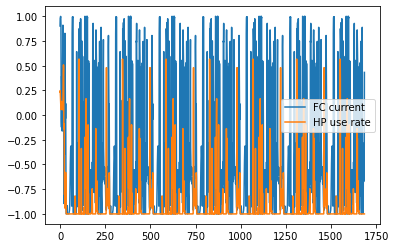

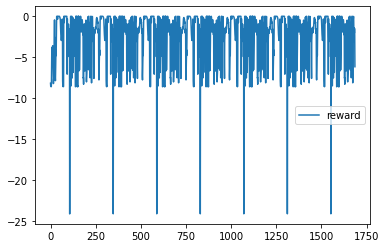

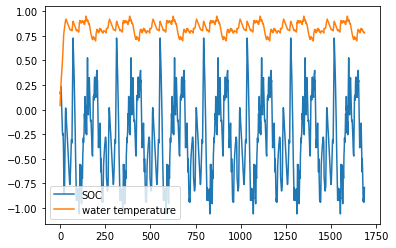

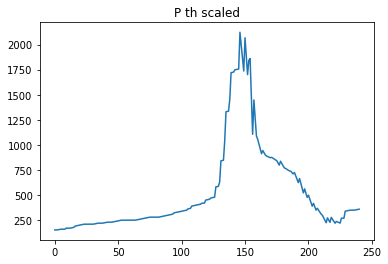

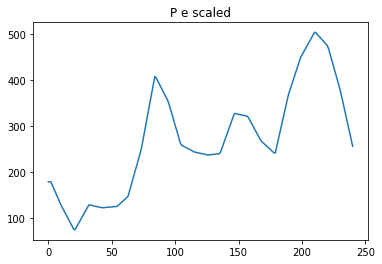

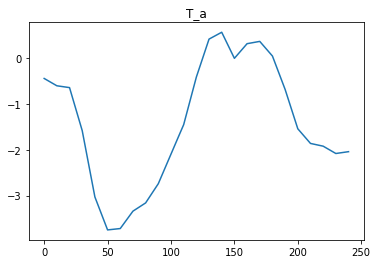

In [ ]:
import numpy as np
import torch
import gym
import argparse
import os
import matplotlib.pyplot as plt
import utils
import TD3
import OurDDPG
import DDPG
#from fcchpm_gym.envs.fcchpm_env import FcchpmEnv


# env = gym.make('fcchp_env-v0')
# env.reset()

# Runs policy for X episodes and returns average reward
# A fixed seed is used for the eval environment
def eval_policy(policy, env_name, seed, eval_episodes=10):
    #eval_env = gym.make(env_name)
    eval_env = FcchpmEnv()
    eval_env.seed(seed + 100)

    avg_reward = 0.
    for _ in range(eval_episodes):
        state, done = eval_env.reset(), False
        while not done:
            #action = (policy.select_action(np.array(state)) + np.random.normal(0, 0.1, size=2)).clip(-1, 1)
            action = policy.select_action(np.array(state))
            state, reward, done, _ = eval_env.step(action)
            avg_reward += reward

    avg_reward /= eval_episodes

    print("---------------------------------------")
    print(f"Evaluation over {eval_episodes} episodes: {avg_reward:.3f}")
    print("---------------------------------------")
    return avg_reward


# if __name__ == "__main__":

parser = argparse.ArgumentParser()
parser.add_argument("--policy", default="TD3")  # Policy name (TD3, DDPG or OurDDPG)
parser.add_argument("--env", default='fcchpm_env-v0')  # OpenAI gym environment name
parser.add_argument("--seed", default=15, type=int)  # Sets Gym, PyTorch and Numpy seeds
parser.add_argument("--start_timesteps", default=25e3, type=int)  # Time steps initial random policy is used
parser.add_argument("--eval_freq", default=5e3, type=int)  # How often (time steps) we evaluate
parser.add_argument("--max_timesteps", default=3e6, type=int)  # 1e6 defaut Max time steps to run environment
parser.add_argument("--expl_noise", default=0.1)  # Std of Gaussian exploration noise
parser.add_argument("--batch_size", default=256, type=int)  # Batch size for both actor and critic
parser.add_argument("--discount", default=0.99)  # Discount factor
parser.add_argument("--tau", default=0.005)  # Target network update rate
parser.add_argument("--policy_noise", default=0.2)  # Noise added to target policy during critic update
parser.add_argument("--noise_clip", default=0.5)  # Range to clip target policy noise
parser.add_argument("--policy_freq", default=2, type=int)  # Frequency of delayed policy updates
parser.add_argument("--save_model", action="store_false")  # Save model and optimizer parameters
parser.add_argument("--load_model", default="default")  # Model load file name, "" doesn't load, "default" uses file_name
#args = parser.parse_args()
args, unknown = parser.parse_known_args()

file_name = f"{args.policy}_{args.env}_{args.seed}"
print("---------------------------------------")
print(f"Policy: {args.policy}, Env: {args.env}, Seed: {args.seed}")
print("---------------------------------------")

if not os.path.exists("./results"):
    os.makedirs("./results")

if args.save_model and not os.path.exists("./models"):
    os.makedirs("./models")

#env = gym.make(args.env)
env = FcchpmEnv()
# print(env.action_space)
# print(env.observation_space)
# Set seeds
env.seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

kwargs = {
    "state_dim": state_dim,
    "action_dim": action_dim,
    "max_action": max_action,
    "discount": args.discount,
    "tau": args.tau,
}

# Initialize policy
if args.policy == "TD3":
    # Target policy smoothing is scaled wrt the action scale
    kwargs["policy_noise"] = args.policy_noise * max_action
    kwargs["noise_clip"] = args.noise_clip * max_action
    kwargs["policy_freq"] = args.policy_freq
    policy = TD3.TD3(**kwargs)
elif args.policy == "OurDDPG":
    policy = OurDDPG.DDPG(**kwargs)
elif args.policy == "DDPG":
    policy = DDPG.DDPG(**kwargs)

if args.load_model != "":
    policy_file = file_name if args.load_model == "default" else args.load_model
    policy.load(f"./models/{policy_file}")

replay_buffer = utils.ReplayBuffer(state_dim, action_dim)

# Evaluate untrained policy
evaluations = [eval_policy(policy, args.env, args.seed)]

N_sim = env.N_step-1

state, done = env.reset(), False
action_trajectory = np.zeros((N_sim,action_dim))
state_trajectory = np.zeros((N_sim,state_dim))
reward_trajectory = np.zeros((N_sim,1))
k = 0
action_dp = np.load('DP_action.npy')
for k in range(N_sim):
    #action = (policy.select_action(np.array(state)) + np.random.normal(0, 0.1, size=2)).clip(-1, 1)
    action = policy.select_action(np.array(state)) # + np.random.normal(0, 0.1, size=2)).clip(-1, 1)
    state, reward, done, _ = env.step(action)
    action_trajectory[k, :] = action
    state_trajectory[k, :] = state
    reward_trajectory[k, :] = reward

print(np.sum(reward_trajectory))
plt.plot(action_trajectory[:, 0],label='FC current')
plt.plot(action_trajectory[:, 1],label='HP use rate')
plt.legend()
plt.show()

plt.plot(reward_trajectory[:,0],label='reward')
plt.legend()
plt.show()

plt.plot(state_trajectory[:, 0],label='SOC')
plt.plot(state_trajectory[:, 1],label='water temperature')
plt.legend()
plt.show()

#%%
P_load_th = np.load('data.npy')[0][0]*1000   # thermal load (W)
P_load_e = np.load('data.npy')[1][0]*1000  # elec load (W)
T_a = np.load('data.npy')[2][0]  # elec load (W)

plt.plot(P_load_th)
plt.title('P th scaled')
plt.show()

plt.plot(P_load_e)
plt.title('P e scaled')
plt.show()

plt.plot(T_a)
plt.title('T_a')
plt.show()


# New Section